# Smart Home Energy Consumption Forecasting
**End-to-end ML pipeline: Preprocessing → EDA → Feature Engineering → Model Training → Evaluation**

# Imports

In [1]:
# import sys # installing Packages for non-colab users 
# !{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn xgboost


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from time import time

import os
os.makedirs("outputs", exist_ok=True)

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## Step 1: Data Preprocessing

In [2]:
df = pd.read_csv("smart_home_energy_usage_dataset.csv")

# Strip whitespace from column names to avoid hidden KeyErrors
df.columns = df.columns.str.strip()

# Convert BEFORE sorting
df["DateTime"] = pd.to_datetime(df["DateTime"])
df = df.sort_values(["Home_ID", "DateTime"]).reset_index(drop=True)

# This dataset has no missing values so no imputation needed.
# If you ever add missing data: df.ffill() then df.bfill() is safe in pandas 3.x
# DO NOT use groupby().apply() for imputation in pandas 3.x — it drops the group column.

print(f"Dataset: {df.shape[0]:,} rows | {df['Home_ID'].nunique()} homes")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Date range: {df['DateTime'].min()} -> {df['DateTime'].max()}")
df.head()

Dataset: 500 rows | 100 homes
Missing values: 0
Date range: 2025-01-01 00:00:00 -> 2025-03-01 00:00:00


,Home_ID,DateTime,Temperature_C,Humidity_%,Light_Lux,Appliance_Usage_kWh,HVAC_Usage_kWh,Water_Heater_kWh,Total_Energy_kWh,Motion_Sensor,Room
0,H001,2025-01-20 15:03:14.789579158,16.4,42.4,508.0,3.33,4.37,0.52,8.22,Inactive,Bedroom
1,H001,2025-02-03 19:34:30.541082164,29.2,79.5,529.0,4.98,0.64,5.14,10.76,Inactive,Living Room
2,H002,2025-01-22 18:07:56.152304609,33.6,61.6,894.0,0.84,8.98,2.27,12.09,Inactive,Bedroom
3,H002,2025-02-26 20:55:18.637274549,21.7,62.3,988.0,0.99,5.89,1.04,7.92,Active,Bathroom
4,H003,2025-01-29 23:13:49.659318637,29.8,72.2,845.0,1.10,1.44,5.80,8.34,Active,Living Room


## Step 2: Exploratory Data Analysis (EDA)

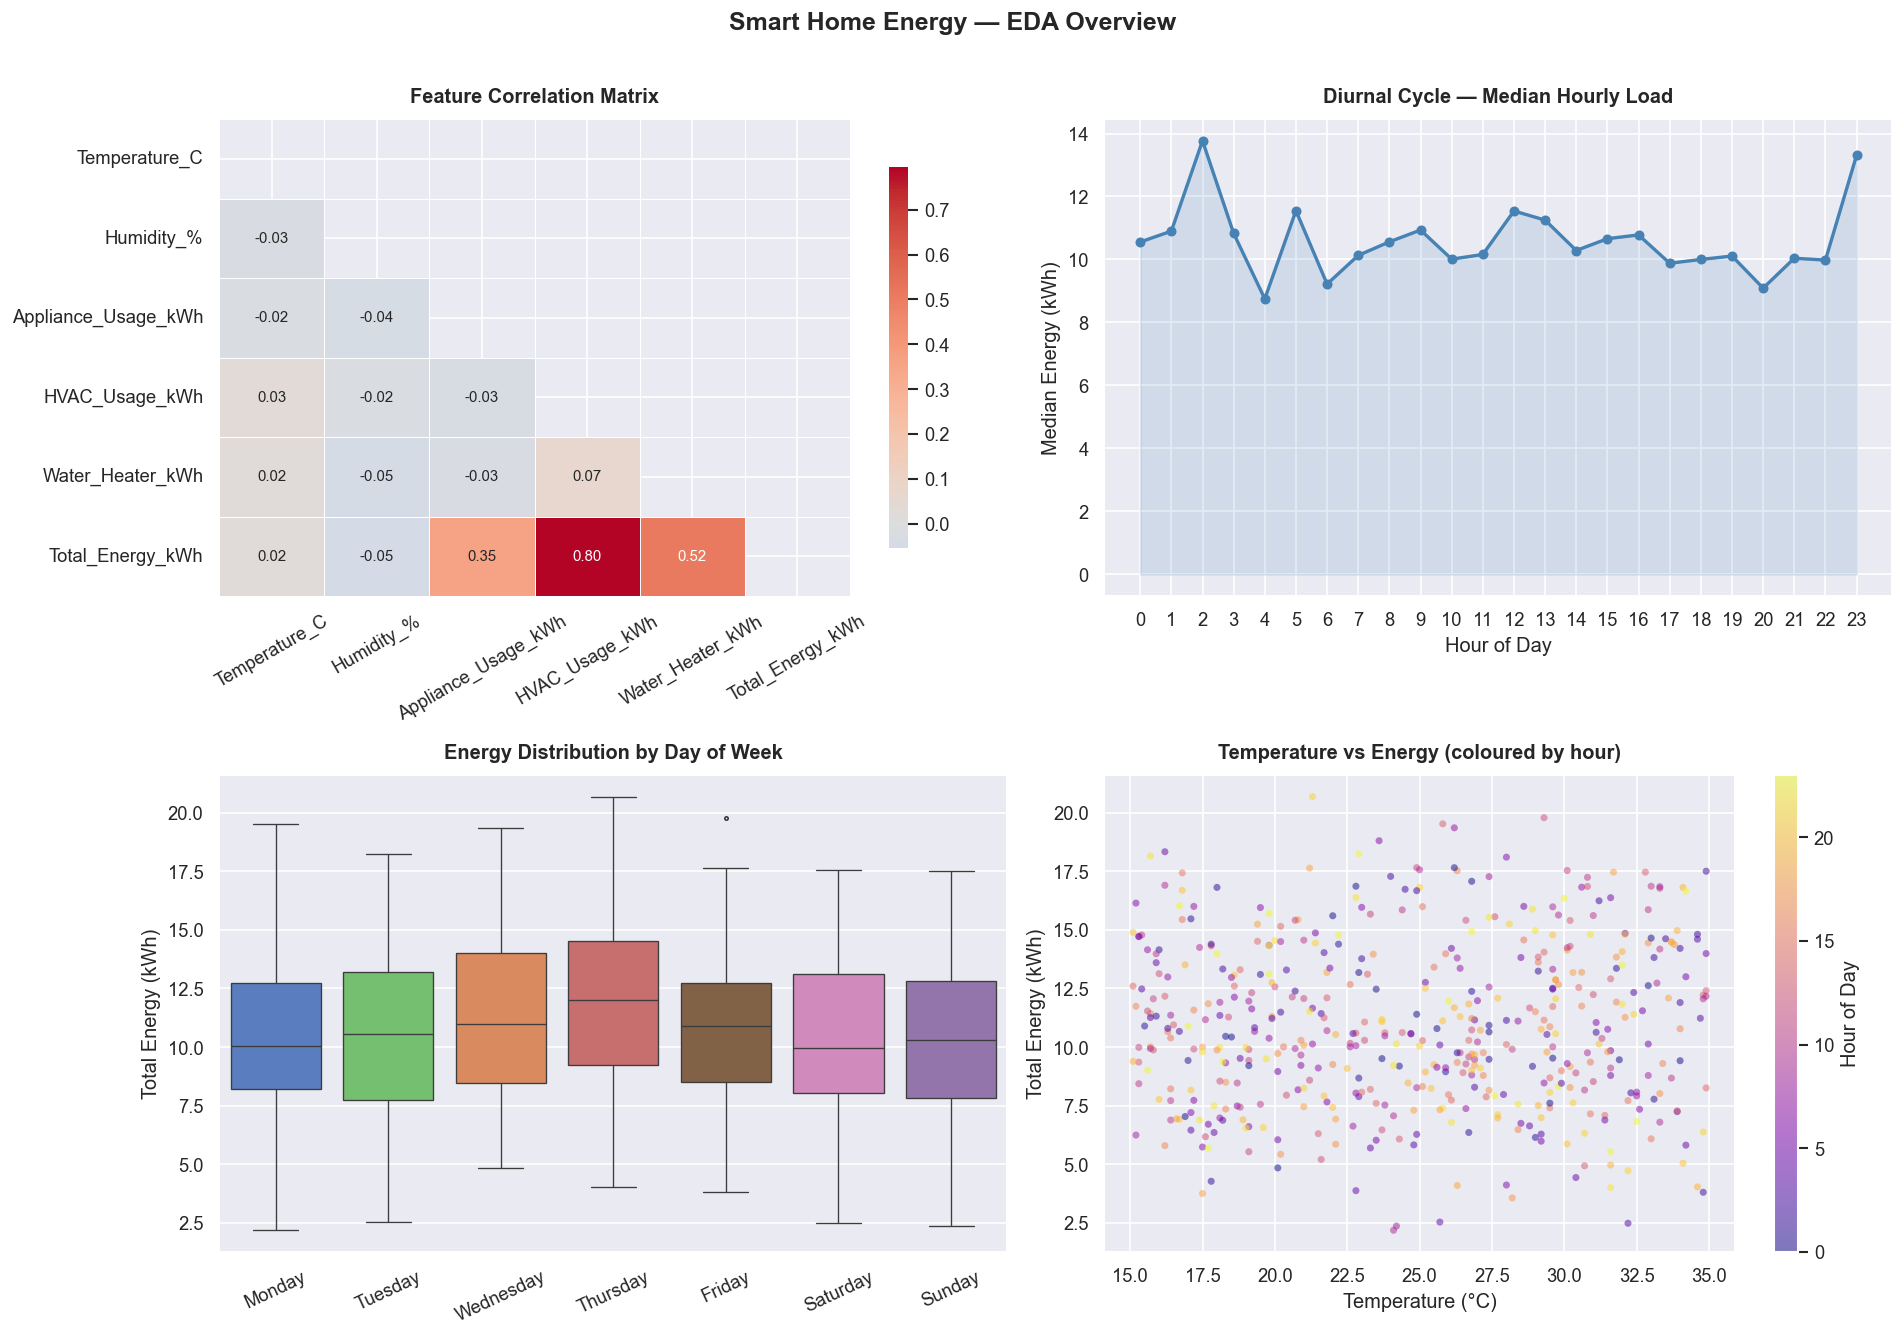

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Smart Home Energy — EDA Overview", fontsize=15, fontweight="bold", y=1.01)

# 2a. Correlation heatmap
numeric_cols = ["Temperature_C", "Humidity_%", "Appliance_Usage_kWh",
                "HVAC_Usage_kWh", "Water_Heater_kWh", "Total_Energy_kWh"]
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[0, 0], cbar_kws={"shrink": 0.8},
            linewidths=0.5, annot_kws={"size": 9})
axes[0, 0].set_title("Feature Correlation Matrix", fontweight="bold", pad=10)
axes[0, 0].tick_params(axis="x", rotation=30)

# 2b. Diurnal cycle
hourly = df.groupby(df["DateTime"].dt.hour)["Total_Energy_kWh"].median()
axes[0, 1].plot(hourly.index, hourly.values, marker="o", linewidth=2,
                color="steelblue", markersize=5)
axes[0, 1].fill_between(hourly.index, hourly.values, alpha=0.15, color="steelblue")
axes[0, 1].set_xlabel("Hour of Day")
axes[0, 1].set_ylabel("Median Energy (kWh)")
axes[0, 1].set_title("Diurnal Cycle — Median Hourly Load", fontweight="bold", pad=10)
axes[0, 1].set_xticks(range(0, 24))

# 2c. Energy by day of week
df["DayName"] = df["DateTime"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.boxplot(data=df, x="DayName", y="Total_Energy_kWh", order=day_order,
            hue="DayName", legend=False, palette="muted", ax=axes[1, 0],
            fliersize=2, linewidth=0.8)
axes[1, 0].set_title("Energy Distribution by Day of Week", fontweight="bold", pad=10)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Total Energy (kWh)")
axes[1, 0].tick_params(axis="x", rotation=25)

# 2d. Temperature vs Energy scatter
sample = df.sample(min(3000, len(df)), random_state=42)
sc = axes[1, 1].scatter(sample["Temperature_C"], sample["Total_Energy_kWh"],
                        c=sample["DateTime"].dt.hour, cmap="plasma",
                        alpha=0.5, s=18, edgecolors="none")
plt.colorbar(sc, ax=axes[1, 1], label="Hour of Day")
axes[1, 1].set_xlabel("Temperature (°C)")
axes[1, 1].set_ylabel("Total Energy (kWh)")
axes[1, 1].set_title("Temperature vs Energy (coloured by hour)", fontweight="bold", pad=10)

plt.tight_layout()
plt.savefig("outputs/eda_overview.png", bbox_inches="tight", dpi=150)
plt.show()

## Step 3: Feature Engineering

In [4]:
# --- 1. Basic Time Features ---
df["Hour"]      = df["DateTime"].dt.hour
df["DayOfWeek"] = df["DateTime"].dt.dayofweek
df["Month"]     = df["DateTime"].dt.month
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

# --- 2. Cyclical Encoding ---
df["Hour_sin"]  = np.sin(2 * np.pi * df["Hour"]  / 24)
df["Hour_cos"]  = np.cos(2 * np.pi * df["Hour"]  / 24)
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

# --- 3. Encode Categorical Columns ---
# Motion_Sensor and Room are IoT sensor readings — encode them as numeric
df["Motion_Binary"] = (df["Motion_Sensor"] == "Active").astype(int)
df["Room_Encoded"]  = df["Room"].map(
    {"Bedroom": 0, "Bathroom": 1, "Living Room": 2, "Kitchen": 3}
)

# --- 4. Interaction Feature ---
# HVAC load amplified by temperature — captures heating/cooling demand
df["HVAC_x_Temp"] = df["HVAC_Usage_kWh"] * df["Temperature_C"]

# --- 5. Handle NaNs Safely ---
print(f"Rows before dropping NaNs: {len(df):,}")
df = df.dropna().reset_index(drop=True)
print(f"Rows after dropping NaNs: {len(df):,}")

# --- 6. Define Features ---

# Linear models get environmental + contextual features only
# Sub-meters excluded because Total = Appliance + HVAC + Water_Heater exactly
# which causes linear models to trivially learn the summation (data leakage)
FEATURES_LINEAR = [
    "Temperature_C", "Humidity_%", "Light_Lux",
    "Motion_Binary", "Room_Encoded", "HVAC_x_Temp",
    "Hour_sin", "Hour_cos", "Month_sin", "Month_cos",
    "DayOfWeek", "IsWeekend",
]

# Tree models get the full feature set including sub-meter IoT sensor readings
# Tree models handle the sub-meter features correctly because they learn
# non-linear thresholds rather than the exact arithmetic summation
FEATURES_TREE = [
    "Appliance_Usage_kWh", "HVAC_Usage_kWh", "Water_Heater_kWh",
    "Temperature_C", "Humidity_%", "Light_Lux",
    "Motion_Binary", "Room_Encoded", "HVAC_x_Temp",
    "Hour_sin", "Hour_cos", "Month_sin", "Month_cos",
    "DayOfWeek", "IsWeekend",
]

# --- 7. Chronological Train/Test Split ---
cutoff_date = df["DateTime"].quantile(0.8)
train_mask  = df["DateTime"] <= cutoff_date

df_train = df[train_mask]
df_test  = df[~train_mask]

# Tree feature sets (unscaled — tree models don't need scaling)
X_train = df_train[FEATURES_TREE]
X_test  = df_test[FEATURES_TREE]
y_train = df_train["Total_Energy_kWh"]
y_test  = df_test["Total_Energy_kWh"]

# Linear feature sets (scaled — linear models are sensitive to feature magnitude)
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(df_train[FEATURES_LINEAR])
X_test_sc    = scaler.transform(df_test[FEATURES_LINEAR])

print(f"Train set: {len(X_train):,} samples | Test set: {len(X_test):,} samples")
print(f"Tree features: {len(FEATURES_TREE)} | Linear features: {len(FEATURES_LINEAR)}")


Rows before dropping NaNs: 500
Rows after dropping NaNs: 500
Train set: 400 samples | Test set: 100 samples
Tree features: 15 | Linear features: 12


## Step 4: Model Training

In [5]:
results = {}

### Linear Regression (Baseline)

In [6]:
# Simple baseline model - no hyperparameters to tune.
# Requires scaled input (X_train_sc / X_test_sc) because it is
# sensitive to feature magnitude.
lr_model = LinearRegression()

# Train the model and record training time in milliseconds
stime = time()
lr_model.fit(X_train_sc, y_train)
train_time_ms = (time() - stime) * 1000

# Use the trained model to make predictions and record inference time
stime = time()
lr_preds = lr_model.predict(X_test_sc)
test_time_ms = (time() - stime) * 1000

# Store results and metrics in dictionary for later comparison
results["Linear Regression"] = {
    "MAE":             mean_absolute_error(y_test, lr_preds),
    "RMSE":            np.sqrt(mean_squared_error(y_test, lr_preds)),
    "R2":              r2_score(y_test, lr_preds),
    "Predictions":     lr_preds,
    "Model":           lr_model,
    "Train Time (ms)": round(train_time_ms, 2),
    "Test Time (ms)":  round(test_time_ms, 2),
}

print(f"Linear Regression -> MAE: {results['Linear Regression']['MAE']:.4f} | "
      f"RMSE: {results['Linear Regression']['RMSE']:.4f} | "
      f"R2: {results['Linear Regression']['R2']:.4f} | "
      f"Train: {results['Linear Regression']['Train Time (ms)']}ms | "
      f"Test: {results['Linear Regression']['Test Time (ms)']}ms")

Linear Regression -> MAE: 2.0000 | RMSE: 2.3876 | R2: 0.5410 | Train: 1.71ms | Test: 0.22ms


### XGBoost (High-Achiever)

In [7]:
# Gradient boosted trees - does NOT need scaled input.
# n_estimators         : max number of boosting rounds
# learning_rate        : shrinks each tree's contribution -> reduces overfitting
# max_depth            : depth of each tree; deeper = more complex patterns
# subsample            : fraction of rows sampled per tree -> adds randomness
# colsample_bytree     : fraction of features sampled per tree -> adds randomness
# early_stopping_rounds: stops training if validation RMSE does not improve
#                        for 20 consecutive rounds -> prevents overfitting automatically
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    eval_metric="rmse",
    random_state=42,
    verbosity=0,
)

# Train the model and record training time in milliseconds
stime = time()
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)
train_time_ms = (time() - stime) * 1000

# Use the trained model to make predictions and record inference time
stime = time()
xgb_preds = xgb_model.predict(X_test)
test_time_ms = (time() - stime) * 1000

# Store results and metrics in dictionary for later comparison
results["XGBoost"] = {
    "MAE":             mean_absolute_error(y_test, xgb_preds),
    "RMSE":            np.sqrt(mean_squared_error(y_test, xgb_preds)),
    "R2":              r2_score(y_test, xgb_preds),
    "Predictions":     xgb_preds,
    "Model":           xgb_model,
    "Train Time (ms)": round(train_time_ms, 2),
    "Test Time (ms)":  round(test_time_ms, 2),
}

print(f"XGBoost -> MAE: {results['XGBoost']['MAE']:.4f} | "
      f"RMSE: {results['XGBoost']['RMSE']:.4f} | "
      f"R2: {results['XGBoost']['R2']:.4f} | "
      f"Train: {results['XGBoost']['Train Time (ms)']}ms | "
      f"Test: {results['XGBoost']['Test Time (ms)']}ms")

XGBoost -> MAE: 0.4885 | RMSE: 0.6146 | R2: 0.9696 | Train: 1088.12ms | Test: 3.81ms


### Random Forest (Average)

In [8]:
# Ensemble of decision trees - does NOT need scaled input.
# n_estimators     : number of decision trees to build
# max_depth        : maximum depth each tree can grow to
# min_samples_split: node cannot split unless minimum number of samples is met
# min_samples_leaf : minimum number of samples required in each leaf node
# random_state     : static random seed to get consistent results
# n_jobs           : uses all available CPU cores to train faster
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

# Train the model and record training time in milliseconds
stime = time()
rf_model.fit(X_train, y_train)
train_time_ms = (time() - stime) * 1000

# Use the trained model to make predictions and record inference time
stime = time()
rf_preds = rf_model.predict(X_test)
test_time_ms = (time() - stime) * 1000

# Store results and metrics in dictionary for later comparison
results["Random Forest"] = {
    "MAE":             mean_absolute_error(y_test, rf_preds),
    "RMSE":            np.sqrt(mean_squared_error(y_test, rf_preds)),
    "R2":              r2_score(y_test, rf_preds),
    "Predictions":     rf_preds,
    "Model":           rf_model,
    "Train Time (ms)": round(train_time_ms, 2),
    "Test Time (ms)":  round(test_time_ms, 2),
}

print(f"Random Forest -> MAE: {results['Random Forest']['MAE']:.4f} | "
      f"RMSE: {results['Random Forest']['RMSE']:.4f} | "
      f"R2: {results['Random Forest']['R2']:.4f} | "
      f"Train: {results['Random Forest']['Train Time (ms)']}ms | "
      f"Test: {results['Random Forest']['Test Time (ms)']}ms")

Random Forest -> MAE: 0.5749 | RMSE: 0.7162 | R2: 0.9587 | Train: 228.78ms | Test: 39.56ms


## Step 5: Evaluation & Visualisation

In [9]:
# 5a. Metrics table — shows baseline model performance before optimization
metrics_df = (
    pd.DataFrame(results)
    .T[["MAE", "RMSE", "R2", "Train Time (ms)", "Test Time (ms)"]]
    .round(4)
    .sort_values("RMSE")
)
print("Model Performance Comparison")
metrics_df

Model Performance Comparison


,MAE,RMSE,R2,Train Time (ms),Test Time (ms)
XGBoost,0.488475,0.614618,0.969581,1088.12,3.81
Random Forest,0.574872,0.716242,0.95869,228.78,39.56
Linear Regression,2.000027,2.387574,0.540964,1.71,0.22


## Step 6: Optimization

### Ridge & Lasso Regression (Optimized Linear Models)

In [10]:
from sklearn.linear_model import RidgeCV, LassoCV

# RidgeCV: adds L2 penalty to shrink large coefficients -> prevents overfitting
# LassoCV: adds L1 penalty which can shrink coefficients to zero -> acts as feature selector
# Both trained on FEATURES_LINEAR only to avoid sub-meter leakage
# alphas: range of regularization strengths to test (small = less penalty, large = more)
ridge_model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
lasso_model = LassoCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0], cv=5, max_iter=5000)

# --- Ridge ---
# Train the model and record training time in milliseconds
stime = time()
ridge_model.fit(X_train_sc, y_train)
train_time_ms = (time() - stime) * 1000

# Use the trained model to make predictions and record inference time
stime = time()
ridge_preds = ridge_model.predict(X_test_sc)
test_time_ms = (time() - stime) * 1000

# Store results and metrics in dictionary for later comparison
results["Ridge Regression"] = {
    "MAE":             mean_absolute_error(y_test, ridge_preds),
    "RMSE":            np.sqrt(mean_squared_error(y_test, ridge_preds)),
    "R2":              r2_score(y_test, ridge_preds),
    "Predictions":     ridge_preds,
    "Model":           ridge_model,
    "Train Time (ms)": round(train_time_ms, 2),
    "Test Time (ms)":  round(test_time_ms, 2),
}

print(f"Ridge (alpha={ridge_model.alpha_:.4f}) -> "
      f"MAE: {results['Ridge Regression']['MAE']:.4f} | "
      f"RMSE: {results['Ridge Regression']['RMSE']:.4f} | "
      f"R2: {results['Ridge Regression']['R2']:.4f} | "
      f"Train: {results['Ridge Regression']['Train Time (ms)']}ms | "
      f"Test: {results['Ridge Regression']['Test Time (ms)']}ms")

# --- Lasso ---
# Train the model and record training time in milliseconds
stime = time()
lasso_model.fit(X_train_sc, y_train)
train_time_ms = (time() - stime) * 1000

# Use the trained model to make predictions and record inference time
stime = time()
lasso_preds = lasso_model.predict(X_test_sc)
test_time_ms = (time() - stime) * 1000

# Store results and metrics in dictionary for later comparison
results["Lasso Regression"] = {
    "MAE":             mean_absolute_error(y_test, lasso_preds),
    "RMSE":            np.sqrt(mean_squared_error(y_test, lasso_preds)),
    "R2":              r2_score(y_test, lasso_preds),
    "Predictions":     lasso_preds,
    "Model":           lasso_model,
    "Train Time (ms)": round(train_time_ms, 2),
    "Test Time (ms)":  round(test_time_ms, 2),
}

print(f"Lasso (alpha={lasso_model.alpha_:.4f}) -> "
      f"MAE: {results['Lasso Regression']['MAE']:.4f} | "
      f"RMSE: {results['Lasso Regression']['RMSE']:.4f} | "
      f"R2: {results['Lasso Regression']['R2']:.4f} | "
      f"Train: {results['Lasso Regression']['Train Time (ms)']}ms | "
      f"Test: {results['Lasso Regression']['Test Time (ms)']}ms")

Ridge (alpha=10.0000) -> MAE: 2.0017 | RMSE: 2.3906 | R2: 0.5398 | Train: 60.72ms | Test: 0.14ms
Lasso (alpha=0.1000) -> MAE: 2.0026 | RMSE: 2.3790 | R2: 0.5443 | Train: 9.11ms | Test: 0.62ms


### Randomized Search and Time Series Split for XGBoost

In [11]:
# Hyperparameter search space for XGBoost
# n_estimators     : number of boosting rounds
# learning_rate    : model learning speed -> lower = more conservative
# max_depth        : max tree depth -> deeper = more complex patterns
# min_child_weight : minimum sum of instance weight in a child -> controls split difficulty
# subsample        : fraction of rows used per tree -> adds randomness
# colsample_bytree : fraction of features used per tree -> adds randomness
# reg_alpha        : L1 regularization to remove less significant features
# reg_lambda       : L2 regularization to prevent large coefficient values
xgb_param_dict = {
    "n_estimators":     [100, 300, 500, 800],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "max_depth":        [3, 4, 5, 6, 8],
    "min_child_weight": [1, 3, 5],
    "subsample":        [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha":        [0, 0.01, 0.1, 1],
    "reg_lambda":       [1, 2, 5, 10],
}

# TimeSeriesSplit ensures validation always uses future data -> prevents data leakage
tscv = TimeSeriesSplit(n_splits=5)

# RandomizedSearchCV samples n_iter random combinations instead of
# testing every combination like GridSearchCV -> much faster for large search spaces
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,        # model being optimized
    param_distributions=xgb_param_dict, # parameter space to sample from
    n_iter=20,                  # number of random combinations to test
    scoring="neg_root_mean_squared_error", # metric used to select the best model
    cv=tscv,                    # time-aware cross-validation
    random_state=42,            # static seed for reproducibility
    n_jobs=-1,                  # use all available CPU cores
)

# Train and optimize the model, record training time in milliseconds
stime = time()
xgb_search.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
train_time_ms = (time() - stime) * 1000

# Extract the best performing model found during the search
best_xgb = xgb_search.best_estimator_

# Use the best model to make predictions and record inference time
stime = time()
xgb_OP_preds = best_xgb.predict(X_test)
test_time_ms = (time() - stime) * 1000

# Store results and metrics in dictionary for later comparison
results["OP XGBoost"] = {
    "MAE":             mean_absolute_error(y_test, xgb_OP_preds),
    "RMSE":            np.sqrt(mean_squared_error(y_test, xgb_OP_preds)),
    "R2":              r2_score(y_test, xgb_OP_preds),
    "Predictions":     xgb_OP_preds,
    "Model":           best_xgb,
    "Train Time (ms)": round(train_time_ms, 2),
    "Test Time (ms)":  round(test_time_ms, 2),
}

print(f"OP XGBoost -> MAE: {results['OP XGBoost']['MAE']:.4f} | "
      f"RMSE: {results['OP XGBoost']['RMSE']:.4f} | "
      f"R2: {results['OP XGBoost']['R2']:.4f} | "
      f"Train: {results['OP XGBoost']['Train Time (ms)']}ms | "
      f"Test: {results['OP XGBoost']['Test Time (ms)']}ms")

OP XGBoost -> MAE: 0.2971 | RMSE: 0.3711 | R2: 0.9889 | Train: 8662.35ms | Test: 3.2ms


### Randomized Search and Time Series Split for Random Forest


In [12]:
# Hyperparameter search space for Random Forest
# n_estimators     : number of decision trees to build
# max_depth        : maximum depth each tree can grow to (None = unlimited)
# min_samples_split: node cannot split unless this minimum number of samples is met
# min_samples_leaf : minimum number of samples required in each leaf node
# max_features     : number of features considered at each split
#                    sqrt = square root of total features (default, good for large feature sets)
#                    log2 = log base 2 of total features
# bootstrap        : whether to use random subsets of training data for each tree
rf_param_dist = {
    "n_estimators":     [100, 200, 300, 500],
    "max_depth":        [None, 8, 12, 16, 20],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features":     ["sqrt", "log2", None],
    "bootstrap":        [True, False],
}

# TimeSeriesSplit ensures validation always uses future data -> prevents data leakage
tscv = TimeSeriesSplit(n_splits=5)

# RandomizedSearchCV samples n_iter random combinations instead of
# testing every combination like GridSearchCV -> much faster for large search spaces
rf_search = RandomizedSearchCV(
    estimator=rf_model,          # model being optimized
    param_distributions=rf_param_dist, # parameter space to sample from
    n_iter=20,                   # number of random combinations to test
    scoring="neg_root_mean_squared_error", # metric used to select the best model
    cv=tscv,                     # time-aware cross-validation
    random_state=42,             # static seed for reproducibility
    n_jobs=-1,                   # use all available CPU cores
)

# Train and optimize the model, record training time in milliseconds
stime = time()
rf_search.fit(X_train, y_train)
train_time_ms = (time() - stime) * 1000

# Extract the best performing model found during the search
best_rf = rf_search.best_estimator_

# Use the best model to make predictions and record inference time
stime = time()
rf_OP_preds = best_rf.predict(X_test)
test_time_ms = (time() - stime) * 1000

# Store results and metrics in dictionary for later comparison
results["OP Random Forest"] = {
    "MAE":             mean_absolute_error(y_test, rf_OP_preds),
    "RMSE":            np.sqrt(mean_squared_error(y_test, rf_OP_preds)),
    "R2":              r2_score(y_test, rf_OP_preds),
    "Predictions":     rf_OP_preds,
    "Model":           best_rf,
    "Train Time (ms)": round(train_time_ms, 2),
    "Test Time (ms)":  round(test_time_ms, 2),
}

print(f"OP Random Forest -> MAE: {results['OP Random Forest']['MAE']:.4f} | "
      f"RMSE: {results['OP Random Forest']['RMSE']:.4f} | "
      f"R2: {results['OP Random Forest']['R2']:.4f} | "
      f"Train: {results['OP Random Forest']['Train Time (ms)']}ms | "
      f"Test: {results['OP Random Forest']['Test Time (ms)']}ms")

OP Random Forest -> MAE: 0.5879 | RMSE: 0.7294 | R2: 0.9572 | Train: 7662.83ms | Test: 86.15ms


## Step 7: Re-evaluation & Visualisation

In [13]:
# Full metrics table — all models including optimized versions
metrics_df = (
    pd.DataFrame(results)
    .T[["MAE", "RMSE", "R2", "Train Time (ms)", "Test Time (ms)"]]
    .round(4)
    .sort_values("RMSE")
)
print("Model Performance Comparison")
metrics_df

Model Performance Comparison


,MAE,RMSE,R2,Train Time (ms),Test Time (ms)
OP XGBoost,0.297107,0.371063,0.988913,8662.35,3.2
XGBoost,0.488475,0.614618,0.969581,1088.12,3.81
Random Forest,0.574872,0.716242,0.95869,228.78,39.56
OP Random Forest,0.587924,0.729434,0.957154,7662.83,86.15
Lasso Regression,2.002569,2.378958,0.54427,9.11,0.62
Linear Regression,2.000027,2.387574,0.540964,1.71,0.22
Ridge Regression,2.001723,2.390627,0.539789,60.72,0.14


## Step 8: Evaluation Plots


NameError: name 'FEATURES' is not defined

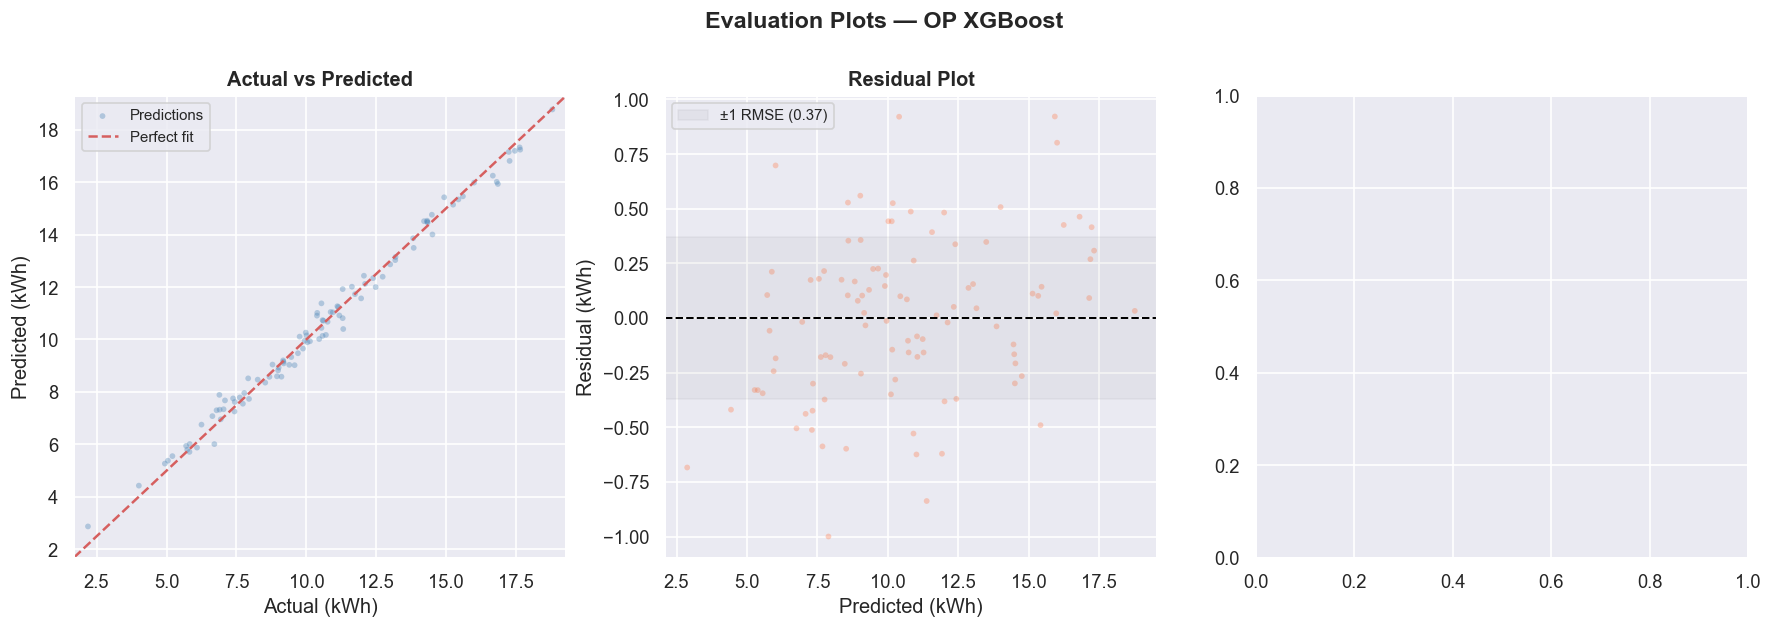

In [ ]:
best_model_name = metrics_df.index[0]  # lowest RMSE
best_preds = results[best_model_name]["Predictions"]
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Evaluation Plots — {best_model_name}", fontsize=14,
             fontweight="bold", y=1.02)

# 8a. Actual vs Predicted
axes[0].scatter(y_test, best_preds, alpha=0.35, s=12,
                color="steelblue", edgecolors="none", label="Predictions")
lims = [min(y_test.min(), best_preds.min()) - 0.5,
        max(y_test.max(), best_preds.max()) + 0.5]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("Actual (kWh)"); axes[0].set_ylabel("Predicted (kWh)")
axes[0].set_title("Actual vs Predicted", fontweight="bold")
axes[0].legend(fontsize=9)

# 8b. Residuals
axes[1].scatter(best_preds, residuals, alpha=0.35, s=12,
                color="coral", edgecolors="none")
axes[1].axhline(0, color="black", linewidth=1.2, linestyle="--")
axes[1].set_xlabel("Predicted (kWh)"); axes[1].set_ylabel("Residual (kWh)")
axes[1].set_title("Residual Plot", fontweight="bold")
# Shade ±1 RMSE band for reference
rmse_val = results[best_model_name]["RMSE"]
axes[1].axhspan(-rmse_val, rmse_val, alpha=0.08, color="grey", label=f"±1 RMSE ({rmse_val:.2f})")
axes[1].legend(fontsize=9)

# 8c. Feature Importance
importance_key = "OP Random Forest" if "OP Random Forest" in results else "OP XGBoost"
if importance_key in results:
    importances = results[importance_key]["Model"].feature_importances_
    feat_series = pd.Series(importances, index=FEATURES_TREE).sort_values(ascending=True)
    colors = ["#2ecc71" if v >= feat_series.median() else "#95a5a6" for v in feat_series]
    feat_series.plot(kind="barh", ax=axes[2], color=colors, edgecolor="none")
    axes[2].set_title("Feature Importances", fontweight="bold")
    axes[2].set_xlabel("Importance Score")
    axes[2].axvline(feat_series.median(), color="red", linestyle="--",
                    linewidth=1, label="Median")
    axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig("outputs/evaluation_plots.png", bbox_inches="tight", dpi=150)
plt.show()

## Step 9: Raspberry Pi Results

### Raspberry Pi Metrics

| Model             | MAE | RMSE | R2 | Training Time (ms) | Testing Time (ms) |
|-------------------|-----|------|----|--------------------|-------------------|
| Linear Regression |     |      |    |                    |                   |
| Random Forest     |     |      |    |                    |                   |
| XGBoost           |     |      |    |                    |                   |



## Step 10: Current vs Raspberry Pi Comparison

### Laptop vs Raspberry Pi Comparison

| Model             | MAE | RMSE | R2 | Training Time (ms) on Laptop | Training Time (ms) on Raspberry Pi | Testing Time (ms) on Laptop | Testing Time (ms) on Raspberry Pi |
|-------------------|-----|------|----|------------------------------|-------------------------------------|-----------------------------|-----------------------------------|
| Linear Regression |     |      |    |                              |                                     |                             |                                   |
| Random Forest     |     |      |    |                              |                                     |                             |                                   |
| XGBoost           |     |      |    |                              |                                     |                             |                                   |